# **Sesión 4 - Análisis y visualización de información química**

📗📘📙📌 **Se seleccionó el target Proteína precursora amiloidea (Amyloid precursor protein) APP para este trabajo** 

**Se obtuvieron las bioactividades reportadas para el target APP en Pubchem (Dataset 1) y en ChEMBL (Dataset2). Luego se realizó una limpieza a cada dataset, se calcularon algunos descriptores químicos y finalmente se concatenaron para realizar un análisis final de los datos** 📌📙📘📗

# Target: Amyloid-beta precursor protein

Although clinical trials targeting Aβ have yielded disappointing results, its central role in plaque formation and disease pathology makes it a biologically validated and structurally well-studied target. Virtual screening provides an opportunity to identify novel small molecules that may interfere with fundamental pathways in ways not previously explored.


* Zhang, Y., Chen, H., Li, R. et al. Amyloid β-based therapy for Alzheimer’s disease: challenges, successes and future. Sig Transduct Target Ther 8, 248 (2023). https://doi.org/10.1038/s41392-023-01484-7

* Karahan H, Hartigan K, Al-Amin MM, et al. Deletion of neuronal Idol ameliorates Alzheimer's disease–related pathologies via APOE receptors. Alzheimer's Dement. 2025; 21:e70949. https://doi.org/10.1002/alz.70949


Amyloid-beta precursor protein (APP) / P05067 · A4_HUMAN

* https://www.uniprot.org/uniprotkb/P05067/entry



📗📘📙📌 **Importe de librerías necesarias para el proyecto** 📌📙📘📗

In [83]:
# Importing necessary libraries

import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import urllib.request

import pip
! pip install rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools
PandasTools.RenderImagesInAllDataFrames(images=True)

! pip install chembl_webresource_client
from chembl_webresource_client.new_client import new_client as search
from chembl_webresource_client.utils import utils

📗📘📙📌 **Formato básico para usar la API de Pubchem** 📌📙📘📗

**The URL Path - Pubchem**

Most – if not all – of the information the service needs to produce its results is encoded into the URL. The general form of the URL has three parts – input, operation, and output – after the common prefix, followed by operation options as URL arguments (after the ‘?’):

In [130]:
# https://pubchem.ncbi.nlm.nih.gov/rest/pug/<input specification>/<operation specification>/[<output specification>][?<operation_options>]

**Bioactivities from Protein - Pubchem**

This operation returns the concise bioactivity data for a given protein. Valid output formats are XML, JSON(P), ASNT/B, and CSV.

https://pubchem.ncbi.nlm.nih.gov/rest/pug/protein/accession/Q01279/concise/JSON

For some proteins with a large amount of data, the operation may time out. In such cases, one can first get the list of AIDs tested against the given protein, e.g.:

https://pubchem.ncbi.nlm.nih.gov/rest/pug/protein/accession/Q01279/aids/TXT

Then aggregate the concise bioactivity data from each AID:

https://pubchem.ncbi.nlm.nih.gov/rest/pug/assay/aid/66438/concise/JSON

📗📘📙📌 **Estructura de URL para obtener bioactividades a partir de proteínas en Pubchem** 📌📙📘📗

In [131]:
# Bioactivities from Protein

# URL = prolog + / + input + / + operation + / + output + options

# Uniprot ID of the target protein: P05067

target = 'P05067'

prolog = 'https://pubchem.ncbi.nlm.nih.gov/rest/pug'


# 🟢 Input
# <domain> = substance | compound | assay | gene | protein | pathway | taxonomy | cell | <other inputs>
# protein domain <namespace> = accession | gi | synonym
input = f'protein/accession/{target}'

# 🟡 Operation
# protein domain <operation specification> = summary | aids | concise | pwaccs
operation = 'concise'

# 🔵 output
# <output specification> = XML | ASNT | ASNB | JSON | JSONP [ ?callback=<callback name> ] | SDF | CSV | PNG | TXT
output = 'CSV'

# 🔴 Options
options = '' # '' Si no se requiere nada en esoecific

# URL construction
url = f'{prolog}/{input}/{operation}/{output}{options}'
print(f'🔗 La URL de búsqueda en Pubchem es: {url}')

🔗 La URL de búsqueda en Pubchem es: https://pubchem.ncbi.nlm.nih.gov/rest/pug/protein/accession/P05067/concise/CSV


📗📘📙📌 **Creación del dataset a partir de los datos obtenidos a través del API de PubChem** 📌📙📘📗

In [132]:
# Creation of a dataset from search results
app_df_pubchem = pd.read_csv(url, low_memory=False)
print(f'📊 El número de compuestos con información de bioactividad para la proteína APP es: {len(app_df_pubchem)}\n')

# Save the initial size of the dataset
initial_size_pubchem = len(app_df_pubchem)
app_df_pubchem.info()

📊 El número de compuestos con información de bioactividad para la proteína APP es: 418493

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418493 entries, 0 to 418492
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   AID                  418493 non-null  int64  
 1   SID                  418493 non-null  int64  
 2   CID                  418444 non-null  float64
 3   Activity Outcome     418493 non-null  object 
 4   Target GeneID        418154 non-null  float64
 5   Activity Name        4410 non-null    object 
 6   Activity Qualifier   2158 non-null    object 
 7   Activity Value [uM]  2920 non-null    float64
 8   Assay Name           418493 non-null  object 
 9   Assay Type           418493 non-null  object 
 10  PubMed ID            8825 non-null    float64
dtypes: float64(4), int64(2), object(5)
memory usage: 35.1+ MB


📗📘📙📌 **Vizualización y limpieza inicial del dataframe** 📌📙📘📗

In [133]:
# Preserving only molecules that contain activity data (IC50, Ki, EC50, etc.)
app_df_pubchem = app_df_pubchem[app_df_pubchem['Activity Value [uM]'].notna()]
print(f'🔶 El número de compuestos con datos de bioactividad para la proteína APP es: {len(app_df_pubchem)}\n')
app_df_pubchem['Activity Name'].value_counts()

🔶 El número de compuestos con datos de bioactividad para la proteína APP es: 2920



Activity Name
IC50        1913
Ki           576
EC50         214
Kd           133
Potency       66
DC50          11
Activity       3
Bmax           3
INH            1
Name: count, dtype: int64

In [134]:
# Presenving only molecules with IC50 values
app_df_pubchem = app_df_pubchem[app_df_pubchem['Activity Name'] == 'IC50']
print(f'🔷 El número de compuestos con datos de IC50 para la proteína APP es: {len(app_df_pubchem)}\n')

# Dropping rows with missing CID values and duplicates
app_df_pubchem = app_df_pubchem.dropna(subset=['CID'])
app_df_pubchem = app_df_pubchem.drop_duplicates(subset=['CID'])
print(f'🔶 El número de compuestos únicos con CID válido es: {len(app_df_pubchem)}')

# Converting the CID column to string type for better handling
app_df_pubchem['CID'] = app_df_pubchem['CID'].astype(int)
app_df_pubchem['CID'] = app_df_pubchem['CID'].astype('string')

# Extracting unique CIDs for better retrival of SMILES
unique_cids = app_df_pubchem['CID'].dropna().unique().astype(str)

🔷 El número de compuestos con datos de IC50 para la proteína APP es: 1913

🔶 El número de compuestos únicos con CID válido es: 1475


📗📘📙📌 **Formato necesario para la busqueda de SMILES (a partir de cid) en PUG-REST** 📌📙📘📗

In [135]:
# Retrieving SMILES from cids in Pubchem
cids = 'cids.text'
prolog = 'https://pubchem.ncbi.nlm.nih.gov/rest/pug'
input = f'compound/cid/{cids}'
operation = 'property/SMILES'
output = 'TXT'
options = ''

# URL construction
url = f'{prolog}/{input}/{operation}/{output}{options}'

📗📘📙📌 **Función para generar una búsqueda estructurada por bloques en PUG-REST y mapeo al dataframe** 📌📙📘📗

In [136]:
# Fuction to get smiles in batch
def get_smiles_batch(cid_batch):
    cids_str = ",".join(cid_batch)
    url = f'{prolog}/compound/cid/{cids_str}/{operation}/{output}{options}'
    response = requests.get(url)
    if response.status_code == 200:
        smiles_list = response.text.strip().split("\n")
        return dict(zip(cid_batch, smiles_list))
    else:
        return {}

# Request with a batch of CIDs
batch_size = 100  # In order not to overload API
cid_smiles_dict = {}

for i in range(0, len(unique_cids), batch_size):
    batch = unique_cids[i:i+batch_size]
    cid_smiles_dict.update(get_smiles_batch(batch))

# Mapping the SMILES to the dataframe
app_df_pubchem['SMILES'] = app_df_pubchem['CID'].astype(str).map(cid_smiles_dict)
app_df_pubchem.sample(5)

,AID,SID,CID,Activity Outcome,Target GeneID,Activity Name,Activity Qualifier,Activity Value [uM],Assay Name,Assay Type,PubMed ID,SMILES
414185,1802105,318833984,122238729,Active,351.0,IC50,NaN,0.0017,Electrochemiluminescence (ECL)-based Immunoass...,Confirmatory,NaN,C1CO[C@H](C2[C@@]1(C3=C(C=CC(=C3OC2)F)F)S(=O)(...
412419,1801320,310304643,89641704,Active,351.0,IC50,NaN,1.0000,In Vitro Inhibition Assay from US Patent US905...,Confirmatory,NaN,C1C[C@@H]2CC3=C(C[C@H]1[C@H]2NS(=O)(=O)C4=CC=C...
399,290593,103522463,44425713,Active,351.0,IC50,=,0.1900,Inhibition of gamma-secretase,Confirmatory,17418571.0,C1CC2=CC=CC=C2N(C1CCCOC(=O)NC3CCN(CC3)CC4=CC=C...
412320,1798079,249813225,67979574,Active,351.0,IC50,NaN,0.0051,sAPPbeta Release Assay from US Patent US102319...,Confirmatory,NaN,CC1=NC2(C3=C(CC24CCC(CC4)OC)C=CC(=C3)C5=CC(=C(...
412413,1801169,253652200,72705046,Active,351.0,IC50,NaN,0.0017,"Release Assay from US Patent US9000183: ""Cyclo...",Confirmatory,NaN,CC1=NC2(C3=CC(=C(C=C3CC24CCC(CC4)OC)F)C5=CC(=C...


📗📘📙📌 **Eliminación de algunas columnas y limpieza adicional del dataframe** 📌📙📘📗

,Pubchem_id,Activity Name,Activity Value [nM],SMILES,Molecules
295,44410509,IC50,6000.0,CCC[C@@H]([C@@H](CC(C)C)C(=O)N[C@H]1CCCCN(C1=O...,
2546,638278,IC50,19700.0,C1=CC(=CC=C1/C=C/C(=O)C2=C(C=C(C=C2)O)O)O,
417847,164617071,IC50,1270.0,CCN(CCCOC1=CC(=C(C=C1)C(=O)/C=C/C2=CC=C(C=C2)N...,
417921,164616487,IC50,3220.0,CC1=CC2=C(C=C1NCC3=C(C=C(C=C3)OC)O)C(=O)N4CCCC...,
557,24786217,IC50,300.0,COC1=C(C=C(C=C1)/C=C/C2=CC(=CC=C2)/C=C/C3=CC(=...,

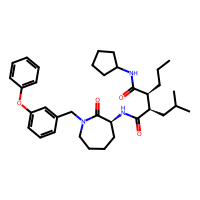
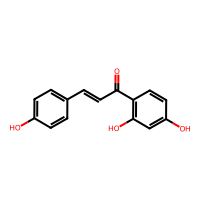
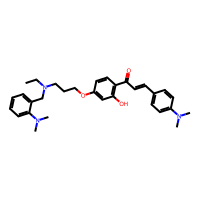
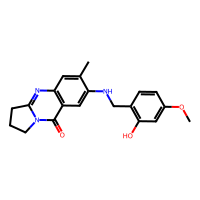
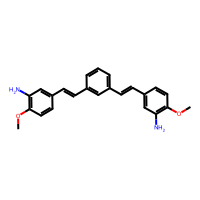

In [137]:
# Removing unnecessary columns
columns_to_remove = ['AID', 'SID', 'Activity Qualifier', 'Activity Outcome', 'Assay Name', 'Target GeneID', 'Assay Type', 'PubMed ID']
app_df_pubchem = app_df_pubchem.drop(columns=columns_to_remove)

# Converting the activity values to nm scale (1 nM = 1000 uM)
app_df_pubchem['Activity Value [uM]'] = app_df_pubchem['Activity Value [uM]'].apply(lambda x: x * 1000)
app_df_pubchem.rename(columns={'Activity Value [uM]': 'Activity Value [nM]'}, inplace=True)

# Renaming the ID column
app_df_pubchem.rename(columns={'CID': 'Pubchem_id'}, inplace=True)
app_df_pubchem.sample(5)

# Removing rows with missing SMILES values
app_df_pubchem = app_df_pubchem.dropna(subset=['SMILES'])


# Adding a column with the 2d structures of the molecules
app_df_pubchem['Molecules'] = app_df_pubchem['SMILES'].apply(lambda x: Chem.MolFromSmiles(x))

# Save the final size of the dataset
final_size_pubchem = len(app_df_pubchem)

app_df_pubchem.sample(5)

📗📘📙📌 **Reporte del proceso de curado del dataset 1** 📌📙📘📗

In [138]:
# Report
print('🧪 Origen de la base de datos: Pubchem\n')
print(f'🔷 Número de compuestos antes del curado: {initial_size_pubchem}\n')
print(f'🔶 Número de compuestos después del curado: {final_size_pubchem}')

🧪 Origen de la base de datos: Pubchem

🔷 Número de compuestos antes del curado: 418493

🔶 Número de compuestos después del curado: 1475


📗📘📙📌 **Cálculo de descriptores** 📌📙📘📗

,Pubchem_id,Activity Name,Activity Value [nM],SMILES,Molecules,MW,HBA,HBD,logP,TPSA,CSP3,NumRings,HetAtoms,RotBonds
340,44425694,IC50,86.00,C1CC2=CC=CC=C2N(C1CCCOC(=O)NCCCN3C=CN=C3)S(=O)...,,516.159804,6,1,4.6433,93.53,0.36,4,10,10
4347,127045902,IC50,22.54,COC1=C(C=C(C=C1)CC(=O)OCC(=O)NC2=C3CCCCC3=NC4=...,,434.184172,6,1,3.8552,86.75,0.32,4,7,7

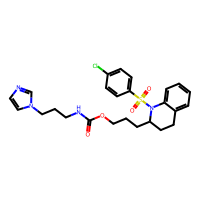
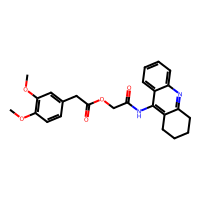

In [139]:
# Calculation of descriptors of interest for the analysis
app_df_pubchem["MW"] = app_df_pubchem["Molecules"].apply(Descriptors.ExactMolWt)
app_df_pubchem["HBA"] = app_df_pubchem["Molecules"].apply(Descriptors.NumHAcceptors)
app_df_pubchem["HBD"] = app_df_pubchem["Molecules"].apply(Descriptors.NumHDonors)
app_df_pubchem["logP"] = app_df_pubchem["Molecules"].apply(Descriptors.MolLogP)
app_df_pubchem["TPSA"] = app_df_pubchem["Molecules"].apply(Descriptors.TPSA)
app_df_pubchem["CSP3"] = app_df_pubchem["Molecules"].apply(Descriptors.FractionCSP3)
app_df_pubchem["NumRings"] = app_df_pubchem["Molecules"].apply(Descriptors.RingCount)
app_df_pubchem["HetAtoms"] = app_df_pubchem["Molecules"].apply(Descriptors.NumHeteroatoms)
app_df_pubchem["RotBonds"] = app_df_pubchem["Molecules"].apply(Descriptors.NumRotatableBonds)

app_df_pubchem.sample(2)

📗📘📙📌 **Filtrado y normalización de los datos** 📌📙📘📗

In [140]:
# Creation of a new dataset with only the descriptors
descriptors_df_pubchem = app_df_pubchem[['MW', 'HBA', 'HBD', 'logP', 'TPSA', 'CSP3', 'NumRings', 'HetAtoms', 'RotBonds']]
descriptors_df_pubchem.sample(5)

,MW,HBA,HBD,logP,TPSA,CSP3,NumRings,HetAtoms,RotBonds
408812,229.073893,3,3,1.9565,73.32,0.000000,2,4,2
408365,574.399525,6,2,3.5324,71.16,0.588235,5,8,11
411501,295.120843,2,2,2.5119,66.40,0.111111,2,4,6
559,480.093621,4,0,6.8243,36.92,0.153846,3,5,8
5163,368.125988,6,2,3.3699,93.06,0.142857,2,6,8


In [141]:
from sklearn.preprocessing import StandardScaler

# z-score: media = 0 std = 1 - z = x-mean/std
scale = StandardScaler(with_mean=True, with_std=True)

# Scaling the descriptor data
scaled_descriptors_pubchem = scale.fit_transform(descriptors_df_pubchem)

# Creating a new dataframe with the scaled descriptors
scaled_descriptors_df_pubchem = pd.DataFrame(scaled_descriptors_pubchem, columns=descriptors_df_pubchem.columns)

# Verification of the scaled data
scaled_descriptors_df_pubchem.describe()

,MW,HBA,HBD,logP,TPSA,CSP3,NumRings,HetAtoms,RotBonds
count,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03,1.475000e+03
mean,4.094653e-16,-1.926896e-17,-9.152754e-17,-2.890343e-16,-2.119585e-16,-3.853791e-17,-1.252482e-16,1.926896e-17,5.780687e-17
std,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00,1.000339e+00
min,-2.462792e+00,-2.620673e+00,-1.256547e+00,-4.996290e+00,-2.291299e+00,-1.527012e+00,-2.715355e+00,-2.397338e+00,-1.379330e+00
25%,-6.775237e-01,-7.202342e-01,-5.285790e-01,-6.437349e-01,-6.059324e-01,-8.271295e-01,-6.437263e-01,-7.448128e-01,-6.262721e-01
50%,-7.373875e-02,-2.451244e-01,-5.285790e-01,-4.269690e-02,-1.486885e-01,-5.725907e-02,4.681646e-02,-4.143077e-01,-1.242333e-01
75%,5.292265e-01,7.050951e-01,1.993893e-01,5.868609e-01,3.240124e-01,6.503996e-01,7.373592e-01,5.772075e-01,3.778054e-01
max,9.060500e+00,6.881522e+00,7.479073e+00,5.492461e+00,1.012623e+01,3.372164e+00,3.499530e+00,8.178825e+00,6.904309e+00


📗📘📙📌 **Matriz y análisis de correlación** 📌📙📘📗

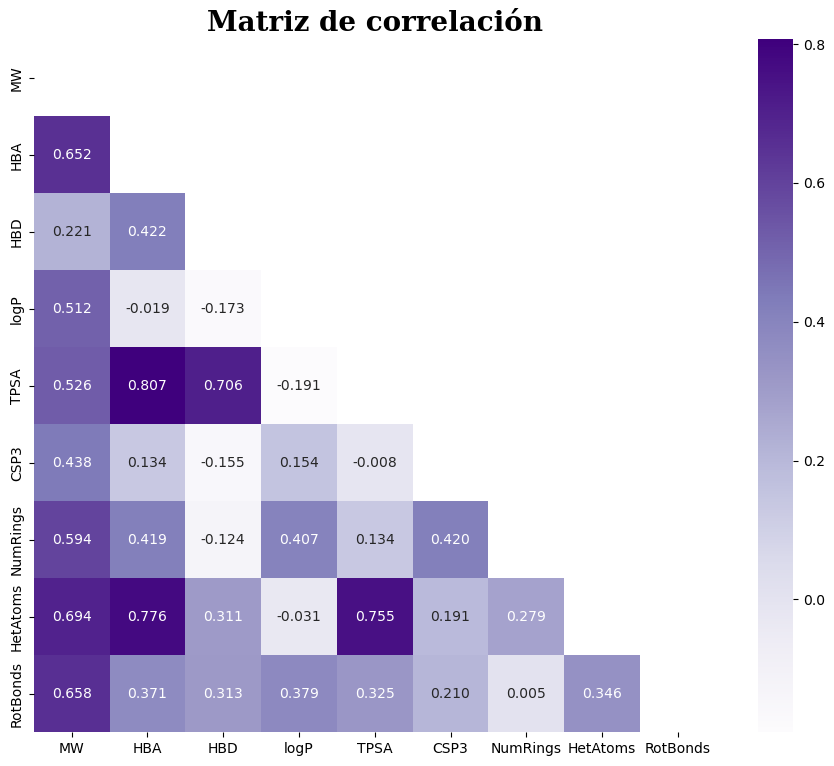

In [142]:
# Correlation matrix of the descriptors
plt.figure(figsize=(11,9))
corr_df = scaled_descriptors_df_pubchem.corr() # To remove the upper triangle of the matrix (we can use a mask)
sns.heatmap(corr_df, annot=True, mask=np.triu(corr_df), cmap='Purples', fmt='.3f')
plt.title('Matriz de correlación', fontsize = 20, fontweight='bold', fontfamily='serif')
plt.show()

In [143]:
# Selection of two descriptors with lower correlation for further analysis
correlation_matrix = scaled_descriptors_df_pubchem.corr()

# Find the pair of descriptors with the lowest correlation
min_corr = 1.0  # Initialize with a high value
descriptor_pair = None

for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = abs(correlation_matrix.iloc[i, j])
        if corr_val < min_corr:
            min_corr = corr_val
            descriptor_pair = (correlation_matrix.columns[i], correlation_matrix.columns[j])

print(f"🔶 Par de descriptores con menor correlación: {descriptor_pair}")
print(f"🔷 Valor de correlación: {min_corr:.4f}")

🔶 Par de descriptores con menor correlación: ('NumRings', 'RotBonds')
🔷 Valor de correlación: 0.0046


📗📘📙📌 **Obtención y análisis de núcleos base (scaffolds)** 📌📙📘📗

,Pubchem_id,Activity Name,Activity Value [nM],SMILES,Molecules,MW,HBA,HBD,logP,TPSA,CSP3,NumRings,HetAtoms,RotBonds,Murcko_SMILES,Scaffold
417877,155451981,IC50,47810.0,CCCCCCNS(=O)(=O)C1=C(C=C(C(=C1)C(=O)O)NCC2=CC=...,,414.101621,5,3,4.10190,108.64,0.388889,2,9,11,c1ccc(NCc2ccco2)cc1,
5237,14837578,IC50,1900.0,COC1=C(C=CC(=C1)/C=C/C(=O)CC(=O)/C=C/C2=C(C(=C...,,368.125988,6,2,3.36990,93.06,0.142857,2,6,8,O=C(/C=C/c1ccccc1)CC(=O)/C=C/c1ccccc1,
414793,156011536,IC50,12300.0,CC1=C(C(=C(C(=C1C2=C(C(=C(C(=C2C)C/C=C(/CC/C=C...,,714.485940,6,4,12.73344,99.38,0.478261,2,6,19,c1ccc(-c2ccccc2)cc1,
415260,154938113,IC50,33.5,CC1=CC(=NC=N1)N2C[C@H]3CC[C@@H](C2)C3NC4=NN5CC...,,465.204386,8,1,4.27072,80.99,0.500000,6,9,5,c1ccc(O[C@H]2CCCn3nc(NC4[C@@H]5CC[C@H]4CN(c4cc...,
412428,71274021,IC50,180.0,C[C@]1(C(COC(=N1)N)(F)F)C2=C(C=CC(=N2)NC(=O)C3...,,381.116107,8,3,1.04060,141.40,0.266667,3,12,3,O=C(Nc1cccc(C2CCOC=N2)n1)c1cnccn1,

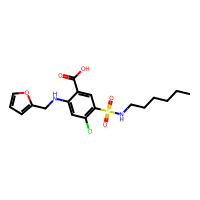
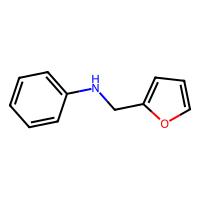
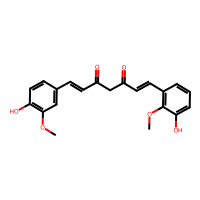
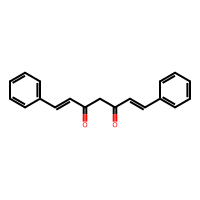
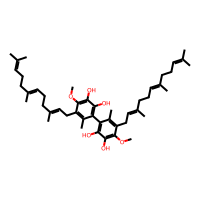
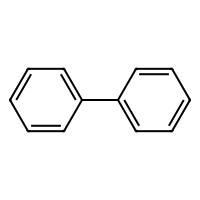
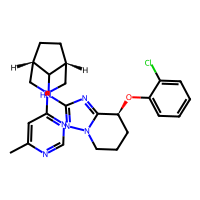
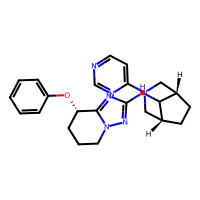
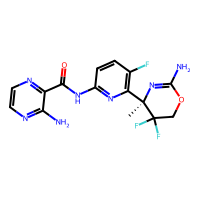
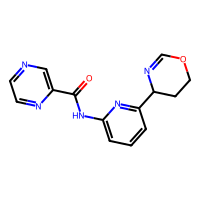

In [144]:
# Adding a new column with the Murcko SMILES of the molecules
PandasTools.AddMurckoToFrame(app_df_pubchem, "Molecules")

# Adding a column with the scaffolds in Mol type
PandasTools.AddMoleculeColumnToFrame(app_df_pubchem, smilesCol="Murcko_SMILES", molCol='Scaffold')

app_df_pubchem.sample(5)

🧪 El dataset cuenta con 602 scaffolds diferentes

🔶 Visualización de los 10 scaffolds más fecuentes en el dataset de Pubchem



[21:34:11] SMILES Parse Error: syntax error while parsing: Linear
[21:34:11] SMILES Parse Error: check for mistakes around position 1:
[21:34:11] Linear
[21:34:11] ^
[21:34:11] SMILES Parse Error: Failed parsing SMILES 'Linear' for input: 'Linear'


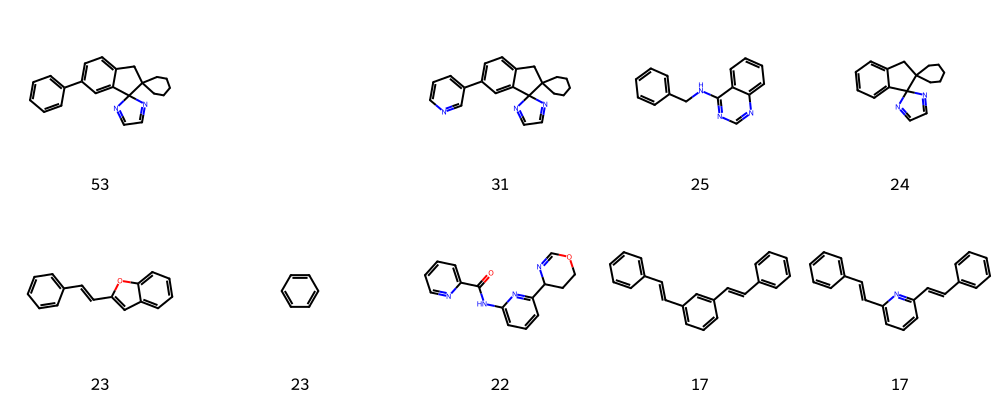

In [145]:
# Group data by scaffolds to count them (value_counts → reset_index)
pubchem_scaffolds = (app_df_pubchem['Murcko_SMILES'].value_counts().rename_axis('Murcko_SMILES').reset_index(name='Amount'))
print(f"🧪 El dataset cuenta con {pubchem_scaffolds.shape[0]} scaffolds diferentes\n")

# Identify and label the linear molecules
pubchem_scaffolds.at[1, 'Murcko_SMILES']='Linear molecule'

# Adding a column with the frequency of each scaffold in the dataset
pubchem_scaffolds['Frequency (%)'] = (pubchem_scaffolds['Amount'] / pubchem_scaffolds['Amount'].sum() * 100)

# Adding a column with the molecules of each scaffold
PandasTools.AddMoleculeColumnToFrame(pubchem_scaffolds, smilesCol='Murcko_SMILES')

# Vizualization of the most frequent scaffolds in the dataset
print(f"🔶 Visualización de los 10 scaffolds más fecuentes en el dataset de Pubchem\n")
PandasTools.FrameToGridImage(pubchem_scaffolds[0:10], column='ROMol', legendsCol='Amount', molsPerRow=5)

📗📘📙📌 **Obtención del dataset 2 y limpieza previa a la concatenación** 📌📙📘📗

In [146]:
# Searching the target in ChEMBL using the uniprot code P05067
target = search.target.filter(target_components__accession="P05067").only(['target_chembl_id', 'pref_name'])

# Converting the results to a DataFrame for better visualization
target_df = pd.DataFrame(target)
target_df

# Identifying the preferred name and ChEMBL ID of the target(s) with uniprot code P05067
app_pref_name = target[0]['pref_name']
app_chembl_id = target[0]['target_chembl_id']
print(f"🧪 El nombre preferido del target con código uniprot P05067 es {app_pref_name} y su ChEMBL ID es {app_chembl_id}")

🧪 El nombre preferido del target con código uniprot P05067 es Amyloid-beta precursor protein y su ChEMBL ID es CHEMBL2487


In [147]:
# Bioactivity (IC50) data retrieval for Amyloid-beta precursor protein (APP)
app_chembl = search.activity.filter(target_chembl_id=app_chembl_id, standard_type="IC50").only(['molecule_chembl_id', 'canonical_smiles', 'standard_value','standard_units'])

# Converting the results to a DataFrame for better visualization
app_df_chembl = pd.DataFrame(app_chembl)

# Duplicate removal (canonical smiles)
app_df_chembl = app_df_chembl.drop_duplicates(subset=['canonical_smiles'])

# Removal of molecules with missing bioactivity values
app_df_chembl= app_df_chembl.dropna(subset=['standard_value'])

# Converting the 'standard_value' column to numeric
app_df_chembl['standard_value'] = pd.to_numeric(app_df_chembl['standard_value'], errors='coerce')
app_df_chembl.sample(3)

,canonical_smiles,molecule_chembl_id,standard_units,standard_value,units,value
1744,CC1=NC2(CCOc3ccc(-c4cc(F)cc(F)c4)cc32)N=C1N,CHEMBL3653659,nM,1700.0,nM,1700.0
504,CCO[C@@H]([C@H]1C[C@@H](C)[C@H]2[C@H](O1)[C@H]...,CHEMBL3403822,nM,110.0,nM,110.0
1362,CCN(CCCOc1ccc(C(=O)/C=C/c2ccc(N(C)C)cc2)c(O)c1...,CHEMBL4857021,nM,1320.0,uM,1.32


In [148]:
# Removing rows with missing SMILES values
app_df_chembl = app_df_chembl.dropna(subset=['canonical_smiles'])

# Adding a column with the 2d structures of the molecules
app_df_chembl['Molecules'] = app_df_chembl['canonical_smiles'].apply(lambda x: Chem.MolFromSmiles(x))

# Calculation of descriptors of interest for the analysis
app_df_chembl["MW"] = app_df_chembl["Molecules"].apply(Descriptors.ExactMolWt)
app_df_chembl["HBA"] = app_df_chembl["Molecules"].apply(Descriptors.NumHAcceptors)
app_df_chembl["HBD"] = app_df_chembl["Molecules"].apply(Descriptors.NumHDonors)
app_df_chembl["logP"] = app_df_chembl["Molecules"].apply(Descriptors.MolLogP)
app_df_chembl["TPSA"] = app_df_chembl["Molecules"].apply(Descriptors.TPSA)
app_df_chembl["CSP3"] = app_df_chembl["Molecules"].apply(Descriptors.FractionCSP3)
app_df_chembl["NumRings"] = app_df_chembl["Molecules"].apply(Descriptors.RingCount)
app_df_chembl["HetAtoms"] = app_df_chembl["Molecules"].apply(Descriptors.NumHeteroatoms)
app_df_chembl["RotBonds"] = app_df_chembl["Molecules"].apply(Descriptors.NumRotatableBonds)

# Adding a new column with the Murcko SMILES of the molecules
PandasTools.AddMurckoToFrame(app_df_chembl, "Molecules")

# Adding a column with the scaffolds in Mol type
PandasTools.AddMoleculeColumnToFrame(app_df_chembl, smilesCol="Murcko_SMILES", molCol='Scaffold')

📗📘📙📌 **Revisión y concatenación entre los dataset 1 y 2** 📌📙📘📗

In [149]:
print(f"🔷 Las columnas del Dataset de PubChem son: {app_df_pubchem.columns.values}\n")
print(f"🔶 Las columnas del Dataset de ChEMBL son: {app_df_chembl.columns.values}")


🔷 Las columnas del Dataset de PubChem son: ['Pubchem_id' 'Activity Name' 'Activity Value [nM]' 'SMILES' 'Molecules'
 'MW' 'HBA' 'HBD' 'logP' 'TPSA' 'CSP3' 'NumRings' 'HetAtoms' 'RotBonds'
 'Murcko_SMILES' 'Scaffold']

🔶 Las columnas del Dataset de ChEMBL son: ['canonical_smiles' 'molecule_chembl_id' 'standard_units' 'standard_value'
 'units' 'value' 'Molecules' 'MW' 'HBA' 'HBD' 'logP' 'TPSA' 'CSP3'
 'NumRings' 'HetAtoms' 'RotBonds' 'Murcko_SMILES' 'Scaffold']


In [ ]:
# Add "Source" column
app_df_chembl["Source"] = "ChEMBL"
app_df_pubchem["Source"] = "PubChem"

# Renaming columns for better merging
app_df_chembl.rename(columns={'molecule_chembl_id': 'Molecule_id', 'canonical_smiles': 'SMILES', 'standard_value': 'Activity Value [nM]'}, inplace=True)
app_df_pubchem.rename(columns={'Pubchem_id': 'Molecule_id'}, inplace=True)

# Dropping unnecessary columns from both datasets
columns_to_remove_chembl = ['standard_units', 'units', 'value']
columns_to_remove_pubchem = ['Activity Name']
app_df_chembl = app_df_chembl.drop(columns=columns_to_remove_chembl)
app_df_pubchem = app_df_pubchem.drop(columns=columns_to_remove_pubchem)

# Merging the datasets
app_df = pd.concat([app_df_pubchem, app_df_chembl], ignore_index=True)

# Drop duplicates based on SMILES
app_df = app_df.drop_duplicates(subset=['SMILES'])
app_df.sample(5)

print(f"🔶 Las columnas del Dataset combinado son: {app_df.columns.values}")

🔶 Las columnas del Dataset combinado son: ['Molecule_id' 'Activity Value [nM]' 'SMILES' 'Molecules' 'MW' 'HBA' 'HBD'
 'logP' 'TPSA' 'CSP3' 'NumRings' 'HetAtoms' 'RotBonds' 'Murcko_SMILES'
 'Scaffold' 'Source']


📗📘📙📌 **Creación de boxplot o violinplot para el par de descriptores con menor correlación ('NumRings' y 'RotBonds')** 📌📙📘📗

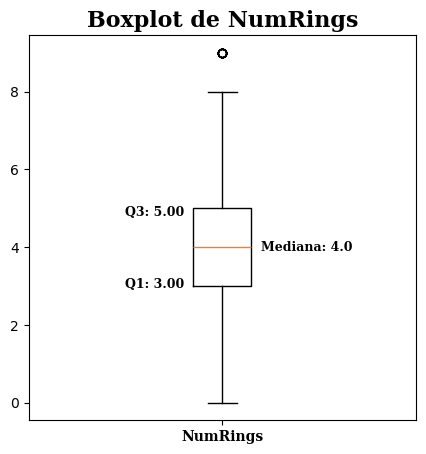

In [ ]:
# Data setting for the boxplot of the descriptor "NumRings"
plt.figure(figsize=(5, 5))
plt.boxplot(app_df['NumRings'])

# Labels setting
plt.title('Boxplot de NumRings', fontsize = 16, fontweight='bold', fontfamily='serif')
plt.xticks([1], ['NumRings'], fontweight='bold', fontfamily='serif')

# Annotations within the graph
plt.annotate(f'Mediana: {round(app_df.NumRings.median(), 1)}', xy=(1.1, 3.9), fontsize = 9, fontweight='bold', fontfamily='serif') # xy=() es la ubicación de la nota
plt.annotate(f'Q3: {app_df.NumRings.quantile(0.75):.2f}', xy=(0.75, 4.8), fontsize = 9, fontweight='bold', fontfamily='serif') # xy=() es la ubicación de la nota
plt.annotate(f'Q1: {app_df.NumRings.quantile(0.25):.2f}', xy=(0.75, 2.95), fontsize = 9, fontweight='bold', fontfamily='serif') # xy=() es la ubicación de la nota
plt.show()

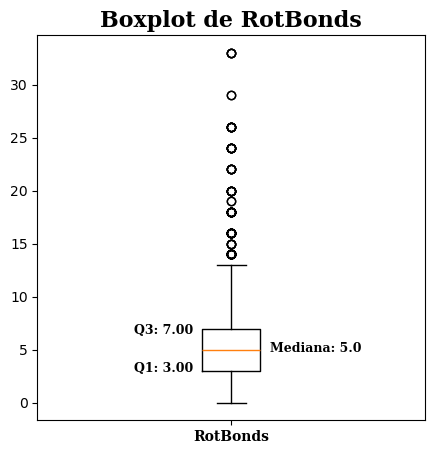

In [238]:
# Data setting for the boxplot of the descriptor "RotBonds"
plt.figure(figsize=(5, 5))
plt.boxplot(app_df['RotBonds'])

# Labels setting
plt.title('Boxplot de RotBonds', fontsize = 16, fontweight='bold', fontfamily='serif')
plt.xticks([1], ['RotBonds'], fontweight='bold', fontfamily='serif')

# Annotations within the graph
plt.annotate(f'Mediana: {round(app_df.RotBonds.median(), 1)}', xy=(1.1, 4.8), fontsize = 9, fontweight='bold', fontfamily='serif') # xy=() es la ubicación de la nota
plt.annotate(f'Q3: {app_df.RotBonds.quantile(0.75):.2f}', xy=(0.75, 6.5), fontsize = 9, fontweight='bold', fontfamily='serif') # xy=() es la ubicación de la nota
plt.annotate(f'Q1: {app_df.RotBonds.quantile(0.25):.2f}', xy=(0.75, 2.9), fontsize = 9, fontweight='bold', fontfamily='serif') # xy=() es la ubicación de la nota
plt.show()

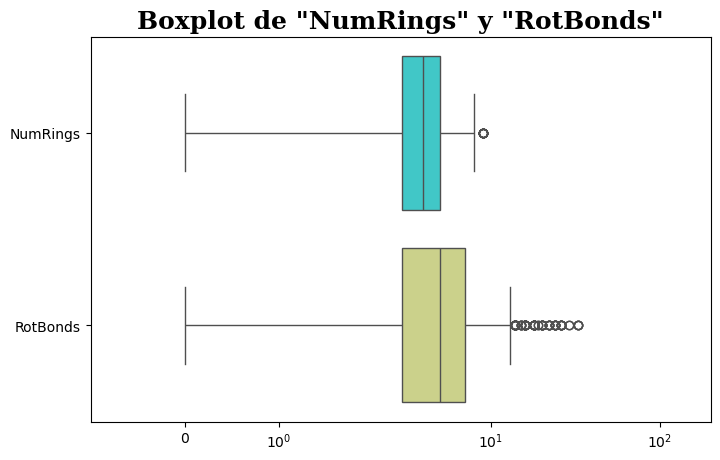

In [237]:
# Combined boxplot for NumRings and RotBonds (logarithmic scale)
plt.figure(figsize=(8,5))
box = sns.boxplot(data=app_df[["NumRings", "RotBonds"]], orient="h", palette="rainbow")

# Logarithmic scale for x-axis
box.set_xscale('symlog')

# Setting limits for better visualization of the data
box.axis(xmin=-1, xmax=200)

plt.title('Boxplot de "NumRings" y "RotBonds"', fontsize = 18, fontweight='bold', fontfamily='serif')
plt.show()


C:\Users\User\AppData\Local\Temp\ipykernel_15212\926195579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=app_df, x='Source', y='RotBonds', palette="Set2")


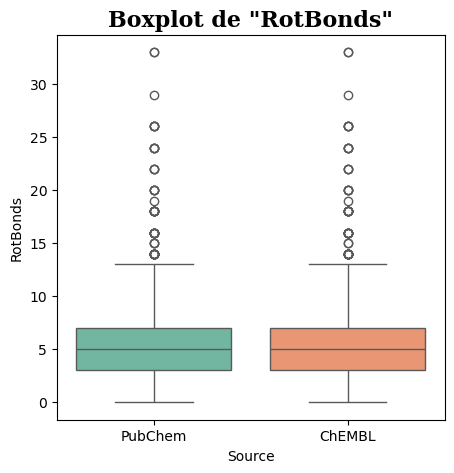

In [ ]:
# Data setting for the boxplot of the descriptor "RotBonds"
plt.figure(figsize=(5, 5))
sns.boxplot(data=app_df, x='Source', y='RotBonds', palette="Set2")

# Labels setting
plt.title('Boxplot de "RotBonds"', fontsize = 16, fontweight='bold', fontfamily='serif')

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_15212\1162765341.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=app_df, x='Source', y='NumRings', palette="Set2")


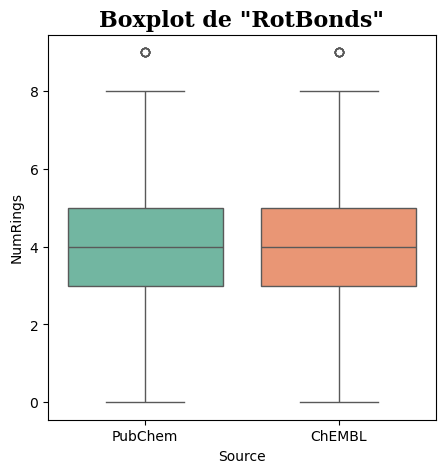

In [239]:
# Data setting for the boxplot of the descriptor "NumRings"
plt.figure(figsize=(5, 5))
sns.boxplot(data=app_df, x='Source', y='NumRings', palette="Set2")

# Labels setting
plt.title('Boxplot de "RotBonds"', fontsize = 16, fontweight='bold', fontfamily='serif')

plt.show()